## Data Mapping for Proteonomics

In [1]:
import sys, os
sys.path.insert(0, "/Users/trivenidhamdhere/Documents/MSc Data Science/MSc Dissertation - AZ/src/scripts")

import re
import pandas as pd
from data_utils import load_clean_parquets, preview

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

In [2]:
tables = load_clean_parquets()
hpa_rna = tables["hpa_rna"]
depmap_expr = tables["depmap_expr"]
geo_expr = tables["geo_expr"]
proteomics = tables["proteomics"]
protein_map = tables["protein_map"]
fusions = tables["fusions"]
mutations = tables["mutations"]
cellosaurus = tables["cellosaurus"]
depmap_profiles = tables["depmap_profiles"]
sample_info = tables["sample_info"]
geo_info = tables["geo_info"]
hpa_desc = tables["hpa_desc"]
metabolomics = tables["metabolomics"]
mirna = tables["mirna"]
signatures = tables["signatures"]

Loaded hpa_rna: (24315372, 6)
Loaded depmap_expr: (1495, 53961)
Loaded geo_expr: (19914, 3268)
Loaded proteomics: (375, 12559)
Loaded protein_map: (12558, 3)
Loaded fusions: (184237, 32)
Loaded mutations: (1066869, 70)
Loaded cellosaurus: (152231, 17)
Loaded depmap_profiles: (3830, 5)
Loaded sample_info: (1840, 29)
Loaded geo_info: (3267, 23)
Loaded hpa_desc: (1206, 7)
Loaded metabolomics: (928, 227)
Loaded mirna: (734, 956)
Loaded signatures: (3021, 12)


In [3]:
proteomics

,depmap_id,a0av96,a0avf1,a0avg3,a0avi4,a0avk6,a0avt1,a0jlt2,a0jnw5,a0mz66,...,q9y6n7-2,q9y4e1-4,q9y6q5-2,q9y6k9-2,q9y3y2-3,q9y4p1-2,q9y6i3-1,q9y5v3-2,q9y575-3,q9y2l9-2
0,ach-000849,0.358567,-0.172066,NaN,NaN,NaN,-0.496842,0.267691,0.045754,0.065342,...,0.255903,-0.081142,1.680544,0.001122,0.684397,0.397332,0.209930,-0.197547,NaN,-1.100381
1,ach-000441,-1.112410,0.339446,NaN,NaN,NaN,-0.395633,-0.262715,-0.414909,-0.396370,...,0.199431,-0.300508,-0.414740,0.178375,-0.387377,-0.008456,-0.482339,0.148685,NaN,0.484499
2,ach-000248,0.855575,-0.181171,NaN,NaN,NaN,-0.284720,-0.436849,0.555351,1.550787,...,-0.849680,0.096941,1.120568,-0.512328,0.102240,-0.204140,0.039421,-0.761104,NaN,-1.191209
3,ach-000684,0.061377,-0.341233,NaN,NaN,NaN,1.481536,-0.006424,0.185271,-0.125160,...,-0.230147,0.148388,-0.162396,0.279161,-0.057371,-0.331465,-0.014308,0.617058,NaN,0.409230
4,ach-000856,0.284258,-0.059558,NaN,NaN,NaN,-0.520511,0.680164,-0.281309,-0.691303,...,-0.024407,0.698199,-0.518353,-0.292139,0.498029,0.283140,-0.123974,-0.560028,NaN,-0.120029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,ach-000846,0.348655,-1.032205,NaN,NaN,NaN,-0.611541,0.473297,-0.523671,1.909424,...,-0.943454,0.274945,0.221292,0.467104,-0.862766,-1.432287,-0.037488,-0.531392,NaN,0.235568
371,ach-000265,-1.442707,-0.684201,NaN,NaN,NaN,-0.729435,0.763294,0.043234,0.659305,...,1.375092,0.813708,-0.336331,0.962541,0.030003,-0.364443,0.060838,1.521803,NaN,-0.144655
372,ach-000006,0.436273,-0.770205,NaN,NaN,NaN,0.965691,-0.135442,0.204895,-0.680679,...,-1.813197,-0.879452,-0.671954,0.506344,0.291667,1.241690,-0.264163,-0.065897,NaN,-0.145264
373,ach-000696,-1.585523,0.289067,NaN,NaN,NaN,0.373398,-0.329539,-0.114584,-0.249955,...,1.406823,0.685588,-0.813471,0.767487,-0.489870,-0.457437,0.373700,0.348390,NaN,0.671977


In [4]:
import numpy as np
import pandas as pd

def audit(df: pd.DataFrame) -> pd.DataFrame:
    n = len(df)
    miss = df.isna().sum()
    pct = (miss.to_numpy(dtype=float) / n * 100).round(1) if n else np.zeros(len(miss))
    return (pd.DataFrame({
        "column":    miss.index,
        "dtype":     df.dtypes.astype(str).to_numpy(),
        "missing_n": miss.to_numpy(),
        "missing_%": pct,
    })
    .sort_values("missing_%", ascending=False)
    .reset_index(drop=True))

In [5]:
pro_miss = audit(proteomics)
pro_miss

,column,dtype,missing_n,missing_%
0,p63135,float64,367,97.9
1,q13291,float64,367,97.9
2,p07288,float64,367,97.9
3,q6mzq0,float64,367,97.9
4,p17752-2,float64,367,97.9
...,...,...,...,...
12554,q15397,float64,0,0.0
12555,q15393,float64,0,0.0
12556,q15392,float64,0,0.0
12557,q15388,float64,0,0.0


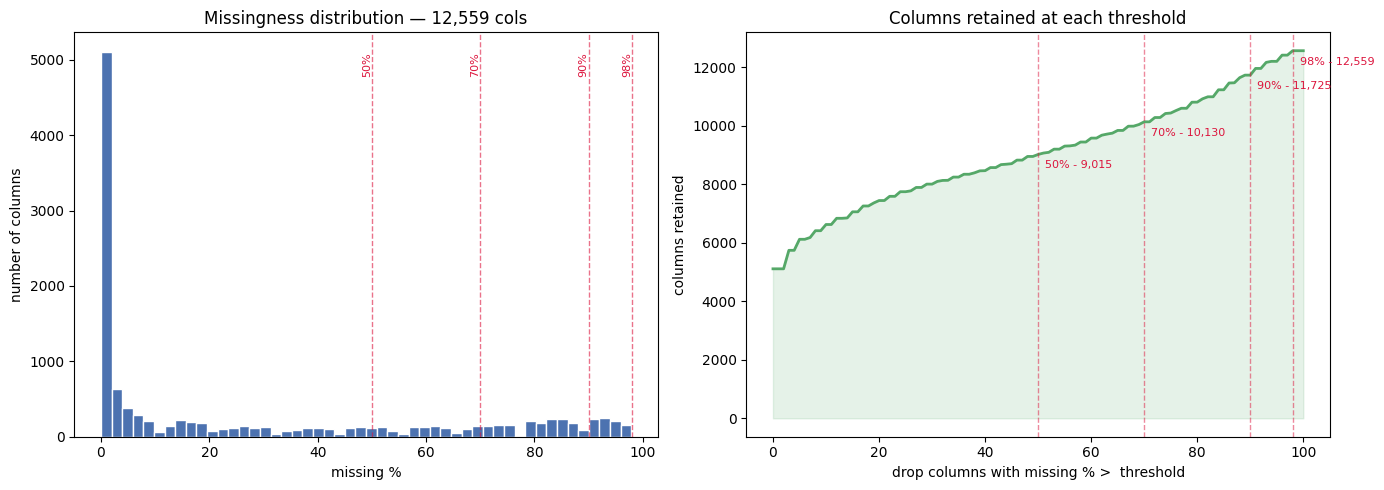

threshold  50% : keep 9,015 / 12,559 cols
threshold  70% : keep 10,130 / 12,559 cols
threshold  90% : keep 11,725 / 12,559 cols
threshold  95% : keep 12,196 / 12,559 cols
threshold  98% : keep 12,559 / 12,559 cols


In [6]:
import numpy as np
import matplotlib.pyplot as plt

miss = (proteomics.isna().mean() * 100).sort_values()
n_cols = len(miss)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: histogram of missingness (find the natural gap) ---
ax[0].hist(miss, bins=50, color="#4C72B0", edgecolor="white")
ax[0].set_xlabel("missing %")
ax[0].set_ylabel("number of columns")
ax[0].set_title(f"Missingness distribution — {n_cols:,} cols")
for t in (50, 70, 90, 98):
    ax[0].axvline(t, color="crimson", ls="--", lw=1, alpha=0.6)
    ax[0].text(t, ax[0].get_ylim()[1]*0.95, f"{t}%", color="crimson",
               rotation=90, va="top", ha="right", fontsize=8)

# --- Right: columns retained vs threshold (the decision curve) ---
thresholds = np.arange(0, 101, 1)
kept = [(miss <= t).sum() for t in thresholds]
ax[1].plot(thresholds, kept, color="#55A868", lw=2)
ax[1].fill_between(thresholds, kept, alpha=0.15, color="#55A868")
ax[1].set_xlabel("drop columns with missing % >  threshold")
ax[1].set_ylabel("columns retained")
ax[1].set_title("Columns retained at each threshold")
for t in (50, 70, 90, 98):
    k = (miss <= t).sum()
    ax[1].axvline(t, color="crimson", ls="--", lw=1, alpha=0.5)
    ax[1].annotate(f"{t}% - {k:,}", (t, k), textcoords="offset points",
                   xytext=(5, -10), fontsize=8, color="crimson")

plt.tight_layout()
plt.show()

# quick numeric summary
for t in (50, 70, 90, 95, 98):
    print(f"threshold {t:>3}% : keep {(miss <= t).sum():>5,} / {n_cols:,} cols")

**Proteomics missingness - decision notes**

- **Distribution:** 12,559 protein columns. One spike of ~5,100 proteins at near-0% missing (reliable core); long, flat tail evenly spread 5–98%. **No natural valley** → threshold is a judgement call, not data-driven.

- **Nature of missingness:** Mostly *below-detection-limit* (mass-spec), i.e. semi-informative — not missing-at-random. 

- **Threshold chosen: drop > 70% missing** - keeps 10k / 12,559 proteins. - will be changed after deciding the model.
  - Rationale: GAT node features must be dense; near-empty columns add no signal and dilute attention.
  - 50% sits in the flat/stable region of the retention curve → robust to small threshold changes.
  - `clean_table()`'s ≥98% rule is too lenient here (drops almost nothing) — proteomics needs a stricter modality-specific cut.

- **Downstream steps (order matters):**
  1. Drop > 70% missing

- **Write-up caveat:** Missingness-threshold dropping biases toward abundant/easily-detected proteins. Defensible but must be a *recorded* decision, not silent.

In [7]:
THRESH = 0.70
before = proteomics.shape[1]
keep = proteomics.columns[proteomics.isna().mean() <= THRESH]
proteomics = proteomics[keep]
print(f"kept {proteomics.shape[1]:} of {before:,} proteins  (dropped {before - proteomics.shape[1]:} at >{int(THRESH*100)}% missing)")

kept 10130 of 12,559 proteins  (dropped 2429 at >70% missing)


## Understanding distribution of the columns

               mean           std           min           max          skew
count  10129.000000  10129.000000  10129.000000  10129.000000  10129.000000
mean      -0.030903      0.880340     -3.216863      2.774763     -0.023568
std        0.083220      0.435004      2.416563      1.341171      0.657380
min       -1.713913      0.275481    -21.091766      0.679013    -10.006506
25%       -0.058309      0.583890     -3.480899      1.815519     -0.239853
50%       -0.021294      0.734125     -2.503111      2.379579      0.009522
75%        0.013067      1.042675     -1.896173      3.382892      0.262420
max        0.457620      5.373312     -0.813775     12.784321      3.556242


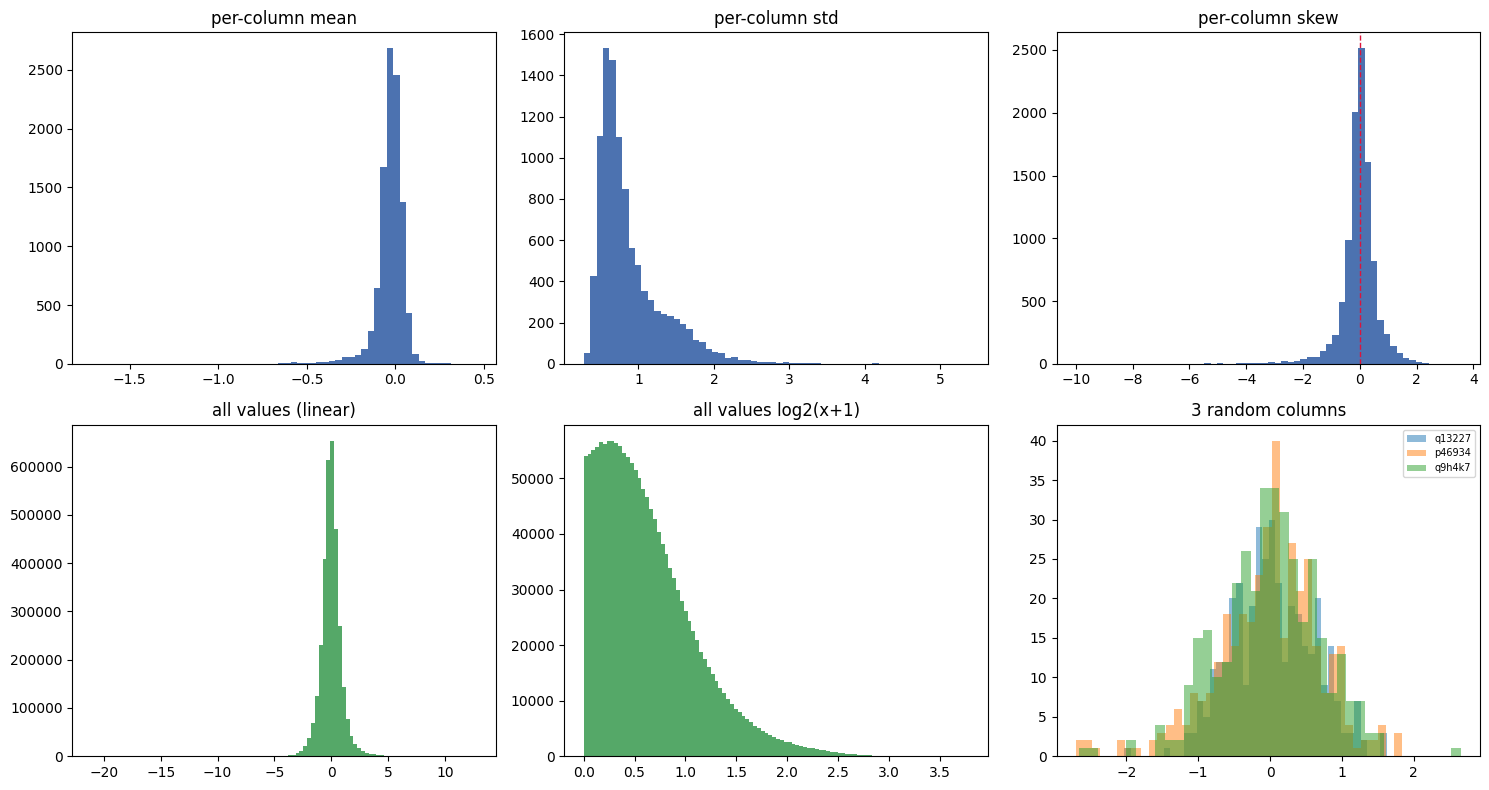

In [8]:
import numpy as np
import matplotlib.pyplot as plt

num = proteomics.select_dtypes("number")

# per-column summary stats
stats = pd.DataFrame({
    "mean":   num.mean(),
    "std":    num.std(),
    "min":    num.min(),
    "max":    num.max(),
    "skew":   num.skew(),
})
print(stats.describe())

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

ax[0,0].hist(stats["mean"].dropna(), bins=60, color="#4C72B0"); ax[0,0].set_title("per-column mean")
ax[0,1].hist(stats["std"].dropna(),  bins=60, color="#4C72B0"); ax[0,1].set_title("per-column std")
ax[0,2].hist(stats["skew"].dropna(), bins=60, color="#4C72B0"); ax[0,2].set_title("per-column skew")
ax[0,2].axvline(0, color="crimson", ls="--", lw=1)

# pooled distribution of ALL values (are they log or linear scale?)
allvals = num.values.ravel()
allvals = allvals[~np.isnan(allvals)]
ax[1,0].hist(allvals, bins=100, color="#55A868"); ax[1,0].set_title("all values (linear)")
pos = allvals[allvals > 0]
ax[1,1].hist(np.log2(pos + 1), bins=100, color="#55A868"); ax[1,1].set_title("all values log2(x+1)")

# spot-check: 3 random columns overlaid
for c in np.random.choice(num.columns, 3, replace=False):
    ax[1,2].hist(num[c].dropna(), bins=40, alpha=0.5, label=c)
ax[1,2].legend(fontsize=7); ax[1,2].set_title("3 random columns")

plt.tight_layout()
plt.show()

**Key finding:** this data is already log-transformed and centred. Don't log it again.
What each panel says:

1. Per-column mean ≈ 0 (tight spike at 0, range roughly −0.5 to +0.3). Values are already centred per protein — this is log-ratio or log-fold-change data, not raw abundance.
2. All values (linear) is symmetric around 0 and spans negatives (−20 to +13). Raw abundances can't be negative, so these are already log/ratio values. This is the decisive panel.
3. All values log2(x+1) panel is misleading here — it only kept positive values (the x>0 filter), so ignore it.
4. Per-column skew centred on 0, mostly within ±2. Roughly symmetric per protein — no global skew problem to fix.
5. Per-column std varies ~0.4 to 2+ (right tail to 5). Proteins live on different spreads — this is the one thing that still needs handling.

In [9]:
import re
from collections import defaultdict

num = proteomics.select_dtypes("number")

# group columns by base UniProt accession (strip -N isoform suffix)
groups = defaultdict(list)
for col in num.columns:
    base = re.sub(r"-\d+$", "", col)
    groups[base].append(col)

# keep only bases that have >1 column (potential redundancy)
multi = {b: cols for b, cols in groups.items() if len(cols) > 1}
print(f"{len(multi)} accessions have multiple isoform columns\n")

# correlate isoforms within each group
rows = []
for base, cols in multi.items():
    c = num[cols].corr()              # pairwise, ignores NaN
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            rows.append({
                "a": cols[i], "b": cols[j],
                "r": round(c.iloc[i, j], 3),
                "n_overlap": num[[cols[i], cols[j]]].dropna().shape[0],
            })

redund = pd.DataFrame(rows).sort_values("r", ascending=False).reset_index(drop=True)
print(redund.head(30))
print(f"\npairs with r > 0.95: {(redund['r'] > 0.95).sum()}")

184 accessions have multiple isoform columns

           a         b      r  n_overlap
0     q9uju6  q9uju6-3  0.928        348
1   o60716-3  o60716-4  0.927        375
2     p49407  p49407-2  0.924        169
3   p62633-3  p62633-4  0.917        312
4     q9h4g0  q9h4g0-2  0.916        357
5     o00499  o00499-8  0.916        330
6   p10636-8  p10636-2  0.914         72
7     q9hau0  q9hau0-6  0.911        152
8     q70uq0  q70uq0-4  0.910        375
9   p27816-6  p27816-2  0.909        276
10    q13642  q13642-4  0.908        375
11    q14789  q14789-2  0.907        268
12    q6uxd5  q6uxd5-5  0.905        206
13    q9nph3  q9nph3-5  0.904        312
14    o94925  o94925-3  0.897        375
15    q5sw79  q5sw79-2  0.895        240
16    p13674  p13674-2  0.895        339
17    p12814  p12814-4  0.893        375
18    q8tct9  q8tct9-2  0.892        366
19    q9y4i1  q9y4i1-3  0.890        142
20  q6pjt7-9  q6pjt7-5  0.889        366
21    q99729  q99729-3  0.887        375
22    q8n3v

**Findings:**

1. Isoform redundancy check: 184 accessions had multiple isoform columns; max pairwise r = 0.928, 0 pairs > 0.95 - no columns dropped.
2. Decision: retain all isoform columns; correlations are consistent with genuine splice-variant signal, not measurement duplication.

In [10]:
cellline = pd.read_parquet("/Users/trivenidhamdhere/Documents/MSc Data Science/MSc Dissertation - AZ/data/reference/cell_line_lookup.parquet")
gene      = pd.read_parquet("/Users/trivenidhamdhere/Documents/MSc Data Science/MSc Dissertation - AZ/data/reference/gene_lookup.parquet")

for name, df in [("cellline", cellline), ("gene", gene)]:
    print(f"\n{'='*50}\n{name}  —  {df.shape[0]:,} rows x {df.shape[1]:,} cols")
    print(f"{'='*50}")
    print("columns:", list(df.columns)[:15], "..." if df.shape[1] > 15 else "")
    print("index:", df.index.name, "|", df.index[:3].tolist())
    print(df.head(3))


cellline  —  1,840 rows x 6 cols
columns: ['model_id', 'cell_line_name', 'stripped_cell_line_name', 'cvcl_accession', 'synonyms', 'rrid'] 
index: None | [0, 1, 2]
     model_id cell_line_name stripped_cell_line_name cvcl_accession  \
0  ACH-000016         SLR 21                   SLR21      CVCL_V607   
1  ACH-000032     MHH-CALL-3                MHHCALL3      CVCL_0089   
2  ACH-000033      NCI-H1819                NCIH1819      CVCL_1497   

                                            synonyms       rrid  
0                                             SLR 21  CVCL_V607  
1  Mhh-Call 3|MHH cALL 3|MHH-CALL3|MHH-cALL3|MHHC...  CVCL_0089  
2                              H1819|H-1819|NCIH1819  CVCL_1497  

gene  —  19,446 rows x 6 cols
columns: ['ensg_id', 'hgnc_symbol', 'prev_symbols', 'alias_symbols', 'hgnc_id', 'biotype'] 
index: None | [0, 1, 2]
           ensg_id hgnc_symbol prev_symbols                  alias_symbols     hgnc_id         biotype
0  ENSG00000121410        A1BG       

# Mapping the protemoics data to lookup table

In [11]:
# dictionary ACH IDs, normalized
ach_known = set(cellline["model_id"].astype(str).str.strip().str.lower())

# proteomics cell-line IDs (the depmap_id column)
prot_ids = proteomics["depmap_id"].astype(str).str.strip().str.lower()

mapped = prot_ids.isin(ach_known)

n = len(prot_ids)
print(f"mapped  : {mapped.sum():,} / {n:,}  ({mapped.mean()*100:.1f}%)")
print(f"unmapped: {(~mapped).sum():,}")
print(f"duplicates in proteomics depmap_id: {prot_ids.duplicated().sum()}")
print("\nunmapped examples:")
print(proteomics.loc[~mapped, "depmap_id"].head(20).tolist())

mapped  : 375 / 375  (100.0%)
unmapped: 0
duplicates in proteomics depmap_id: 0

unmapped examples:
[]


In [12]:
proteomics

,depmap_id,a0av96,a0avf1,a0avt1,a0jlt2,a0jnw5,a0mz66,a0pk00,a1a4s6,a1a5c7,...,q9y520-7,q9y6n7-2,q9y4e1-4,q9y6q5-2,q9y6k9-2,q9y3y2-3,q9y4p1-2,q9y6i3-1,q9y5v3-2,q9y2l9-2
0,ach-000849,0.358567,-0.172066,-0.496842,0.267691,0.045754,0.065342,-0.463915,-0.366869,NaN,...,0.237877,0.255903,-0.081142,1.680544,0.001122,0.684397,0.397332,0.209930,-0.197547,-1.100381
1,ach-000441,-1.112410,0.339446,-0.395633,-0.262715,-0.414909,-0.396370,1.085493,-0.554844,NaN,...,-0.122494,0.199431,-0.300508,-0.414740,0.178375,-0.387377,-0.008456,-0.482339,0.148685,0.484499
2,ach-000248,0.855575,-0.181171,-0.284720,-0.436849,0.555351,1.550787,-0.395332,0.272207,NaN,...,0.115800,-0.849680,0.096941,1.120568,-0.512328,0.102240,-0.204140,0.039421,-0.761104,-1.191209
3,ach-000684,0.061377,-0.341233,1.481536,-0.006424,0.185271,-0.125160,0.276008,0.264691,NaN,...,0.140373,-0.230147,0.148388,-0.162396,0.279161,-0.057371,-0.331465,-0.014308,0.617058,0.409230
4,ach-000856,0.284258,-0.059558,-0.520511,0.680164,-0.281309,-0.691303,0.014557,0.168444,NaN,...,-0.371946,-0.024407,0.698199,-0.518353,-0.292139,0.498029,0.283140,-0.123974,-0.560028,-0.120029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,ach-000846,0.348655,-1.032205,-0.611541,0.473297,-0.523671,1.909424,-0.599066,-0.563776,NaN,...,0.630795,-0.943454,0.274945,0.221292,0.467104,-0.862766,-1.432287,-0.037488,-0.531392,0.235568
371,ach-000265,-1.442707,-0.684201,-0.729435,0.763294,0.043234,0.659305,-0.953360,-0.299761,NaN,...,0.345401,1.375092,0.813708,-0.336331,0.962541,0.030003,-0.364443,0.060838,1.521803,-0.144655
372,ach-000006,0.436273,-0.770205,0.965691,-0.135442,0.204895,-0.680679,0.292743,-1.175458,NaN,...,0.412440,-1.813197,-0.879452,-0.671954,0.506344,0.291667,1.241690,-0.264163,-0.065897,-0.145264
373,ach-000696,-1.585523,0.289067,0.373398,-0.329539,-0.114584,-0.249955,0.086394,0.611285,NaN,...,0.068338,1.406823,0.685588,-0.813471,0.767487,-0.489870,-0.457437,0.373700,0.348390,0.671977


In [13]:
from pathlib import Path

out = Path("/Users/trivenidhamdhere/Documents/MSc Data Science/"
           "MSc Dissertation - AZ/cleaned_track_data")
out.mkdir(parents=True, exist_ok=True)


for name, df in [("proteomics", proteomics)]:
    path = out / f"{name}.parquet"
    df.to_parquet(path, engine="fastparquet", index=False)
    print(f"saved {name}: {df.shape[0]} rows x {df.shape[1]} cols -> {path}")

saved proteomics: 375 rows x 10130 cols -> /Users/trivenidhamdhere/Documents/MSc Data Science/MSc Dissertation - AZ/cleaned_track_data/proteomics.parquet
